### Imports

In [1]:
import os, json, sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
import seaborn as sns

from utils.exp_utils import extract_data

### Load experiment results

In [2]:
results_dir = "../outputs/experiment_results"

with open(os.path.join(results_dir, "results_mnist_fcnn_lam_0_01.json"), "r") as f:
    results_mnist_fcnn_lam_0_01 = json.load(f)

with open(os.path.join(results_dir, "results_mnist_fcnn_lam_0_0001.json"), "r") as f:
    results_mnist_fcnn_lam_0_0001 = json.load(f)

### Plot

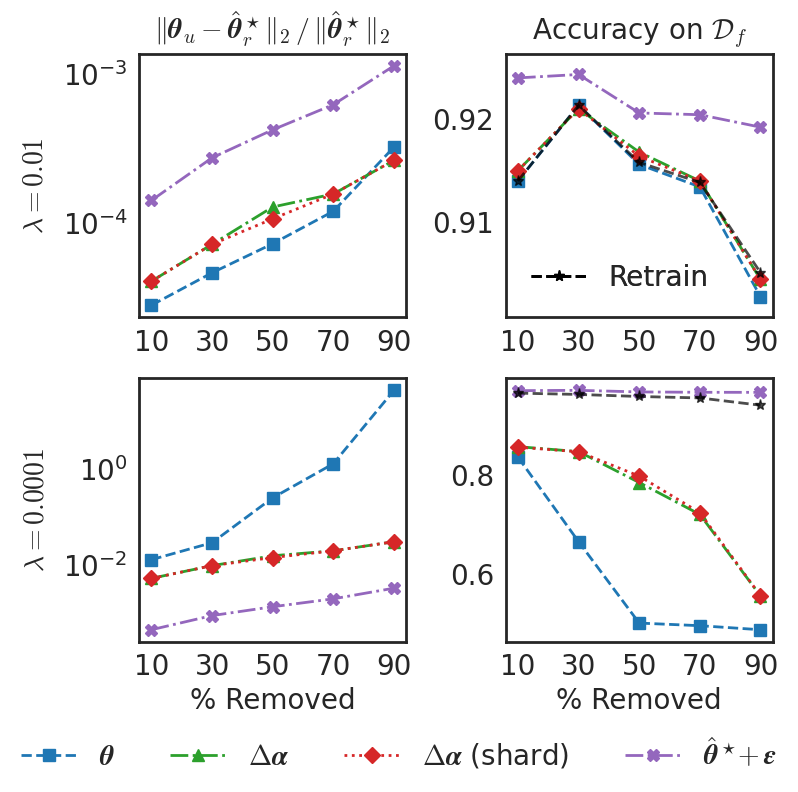

In [4]:
figures_dir = "../outputs/figures"
os.makedirs(figures_dir, exist_ok=True)

# Two rows of the figure
x0, methods_with_runtime0, all_methods0, cold0, warmm0, warms0, rel0, accf0, acct0, accfr0, acctr0 = extract_data(results_mnist_fcnn_lam_0_01)
x1, methods_with_runtime1, all_methods1, cold1, warmm1, warms1, rel1, accf1, acct1, accfr1, acctr1 = extract_data(results_mnist_fcnn_lam_0_0001)

x = x0
methods_with_runtime = methods_with_runtime0
all_methods = all_methods0

rename = {
    "theta": r"$\boldsymbol{\theta}$",
    "operator_wo_sharding": r"$\Delta\boldsymbol{\alpha}$",
    "operator_w_sharding": r"$\Delta\boldsymbol{\alpha}$ (shard)",
    "noise": r"$\hat{\boldsymbol{\theta}}^\star \!\!+ \boldsymbol{\epsilon}$",
}

# titles = [
#     "Cold start runtime (s)",
#     "Warm start runtime (s)",
#     r"$\| \boldsymbol{\theta}_u - \hat{\boldsymbol{\theta}}_r^\star\|_2 / \| \hat{\boldsymbol{\theta}}_r^\star \|_2$",
#     r"Accuracy on $\mathcal{D}_f$",
# ]

style_map = {
    "theta": {"color": "tab:blue", "linestyle": "--", "marker": "s"},
    "materialize_bs100": {"color": "tab:orange", "linestyle": "--", "marker": "s"},
    "operator_wo_sharding": {"color": "tab:green", "linestyle": "-.", "marker": "^"},
    "operator_w_sharding": {"color": "tab:red", "linestyle": ":", "marker": "D"},
    "noise": {"color": "tab:purple", "linestyle": "-.", "marker": "X"},
}

rc_tex = {
    "text.usetex": False,
    "mathtext.fontset": "cm",
}

with plt.rc_context(rc_tex), sns.axes_style("white"), sns.plotting_context("paper", font_scale=1.5):
    fig, axs = plt.subplots(2, 2, figsize=(8, 8.5), sharex=False)

    # font sizes
    title_fs = 20
    label_fs = 20
    tick_fs = 20
    legend_fs = 20

    def plot_one_row(ax_row, x, all_methods, rel, acc, acc_retrain, row_label, show_retrain_label=True):
        ax_rel, ax_acc = ax_row

        # Left column: relative l2 distance
        for method in all_methods:
            st = style_map[method]
            ax_rel.plot(
                x,
                rel[method],
                color=st["color"],
                linestyle=st["linestyle"],
                marker=st["marker"],
                linewidth=2,
                markersize=8,
                label=method,
            )
        ax_rel.set_yscale("log")
        ax_rel.yaxis.set_minor_formatter(mticker.NullFormatter())
        ax_rel.set_xticks(x)
        ax_rel.set_ylabel(row_label, fontsize=label_fs, labelpad=10)

        # Right column: test accuracy
        for method in all_methods:
            st = style_map[method]
            ax_acc.plot(
                x,
                acc[method],
                color=st["color"],
                linestyle=st["linestyle"],
                marker=st["marker"],
                linewidth=2,
                markersize=8,
                label=method,
            )

        # retrain baseline
        ax_acc.plot(
            x,
            acc_retrain,
            color="k",
            linestyle="--",
            marker="*",
            linewidth=2,
            markersize=8,
            alpha=0.7,
            label="retrain",
        )

        all_acc = np.concatenate(
            [np.asarray(acc[m]) for m in all_methods] + [np.asarray(acc_retrain)]
        )
        amin, amax = float(all_acc.min()), float(all_acc.max())
        pad = max(0.002, 0.05 * (amax - amin) if amax > amin else 0.002)
        ax_acc.set_ylim(amin - pad, amax + pad)
        ax_acc.set_xticks(x)

        if show_retrain_label:
            style_handles = [
                Line2D([0], [0], color="k", linestyle="--", marker="*", linewidth=2, markersize=8, label="Retrain"),
            ]
            style_leg = ax_acc.legend(
                handles=style_handles,
                loc="best",
                fontsize=20,
                frameon=False,
            )
            ax_acc.add_artist(style_leg)

    # Top row: lambda = 0.01
    plot_one_row(axs[0], x0, all_methods0, rel0, accf0, accfr0, row_label=r"$\lambda = 0.01$")
    # Bottom row: lambda = 0.0001
    plot_one_row(axs[1], x1, all_methods1, rel1, accf1, accfr1, row_label=r"$\lambda = 0.0001$", show_retrain_label=False)

    # Column titles
    axs[0, 0].set_title(
        r"$\| \boldsymbol{\theta}_u - \hat{\boldsymbol{\theta}}_r^\star\|_2 \,/\, \| \hat{\boldsymbol{\theta}}_r^\star \|_2$",
        pad=10,
        fontsize=title_fs,
    )
    axs[0, 1].set_title(r"Accuracy on $\mathcal{D}_f$", pad=10, fontsize=title_fs)

    # Bottom row x-labels
    axs[1, 0].set_xlabel("% Removed", fontsize=label_fs)
    axs[1, 1].set_xlabel("% Removed", fontsize=label_fs)

    for ax in axs.flat:
        for spine in ax.spines.values():
            spine.set_linewidth(2.0)
        ax.tick_params(axis="both", labelsize=tick_fs, width=1.5)

    # shared method legend at bottom
    method_handles, method_labels = axs[0, 0].get_legend_handles_labels()
    method_labels = [rename.get(lbl, lbl) for lbl in method_labels]

    fig.legend(
        method_handles,
        method_labels,
        loc="lower center",
        ncol=len(method_labels),
        frameon=False,
        bbox_to_anchor=(0.5, 0.05),
        fontsize=legend_fs,
    )

    fig.tight_layout(rect=(0, 0.12, 1, 1))

    fig.savefig(os.path.join(figures_dir, "figure_3.pdf"), bbox_inches="tight")

    plt.show()